In [1]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
import pandas as pd
print(pd.__version__)

3.0.0


In [3]:
train_path = "../data/KDDTrain+.txt"
test_path = "../data/KDDTest+.txt"

print("Paths created successfully!")

Paths created successfully!


In [4]:
columns = [
    'duration','protocol_type','service','flag','src_bytes',
    'dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root',
    'num_file_creations','num_shells','num_access_files',
    'num_outbound_cmds','is_host_login','is_guest_login',
    'count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate',
    'diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','attack','difficulty'
]

print("Total Columns:", len(columns))

Total Columns: 43


In [5]:
train_df = pd.read_csv(
    train_path,
    names=columns
)

test_df = pd.read_csv(
    test_path,
    names=columns
)

print("Training Shape:", train_df.shape)
print("Testing Shape:", test_df.shape)

Training Shape: (125973, 43)
Testing Shape: (22544, 43)


In [9]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [10]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [13]:
train_df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [ ]:
train_df['attack'].value_counts()

attack
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

In [14]:
print("Number of attack classes:")
print(train_df['attack'].nunique())

Number of attack classes:
23


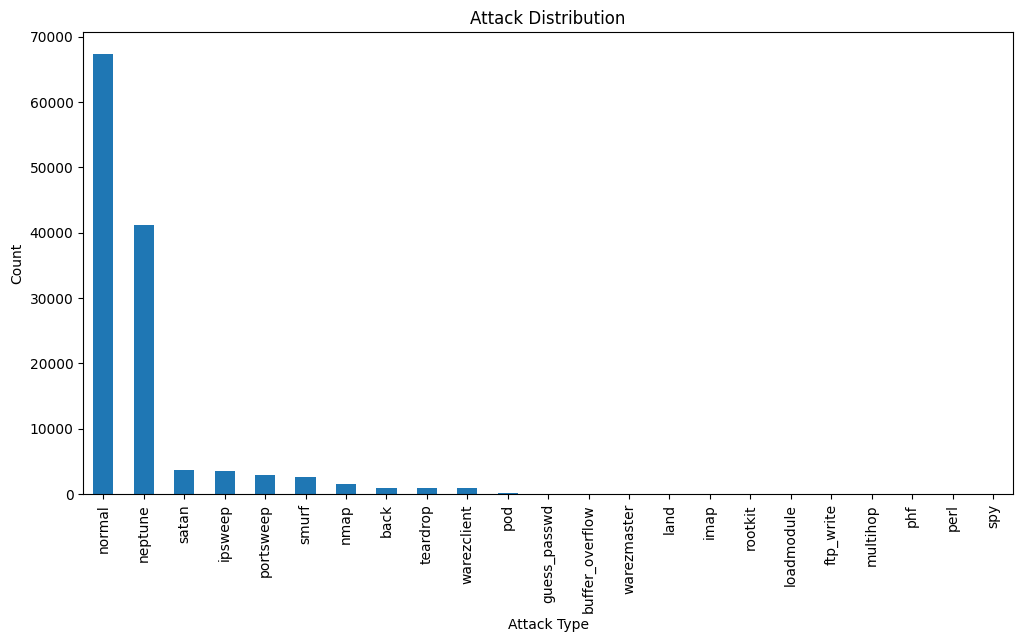

In [15]:
import matplotlib.pyplot as plt

attack_counts = train_df['attack'].value_counts()

plt.figure(figsize=(12,6))
attack_counts.plot(kind='bar')

plt.title('Attack Distribution')
plt.xlabel('Attack Type')
plt.ylabel('Count')

plt.show()

In [16]:
attack_mapping = {

    # Normal
    'normal': 'Normal',

    # DoS
    'back': 'DoS',
    'land': 'DoS',
    'neptune': 'DoS',
    'pod': 'DoS',
    'smurf': 'DoS',
    'teardrop': 'DoS',

    # Probe
    'ipsweep': 'Probe',
    'nmap': 'Probe',
    'portsweep': 'Probe',
    'satan': 'Probe',

    # R2L
    'ftp_write': 'R2L',
    'guess_passwd': 'R2L',
    'imap': 'R2L',
    'multihop': 'R2L',
    'phf': 'R2L',
    'spy': 'R2L',
    'warezclient': 'R2L',
    'warezmaster': 'R2L',

    # U2R
    'buffer_overflow': 'U2R',
    'loadmodule': 'U2R',
    'perl': 'U2R',
    'rootkit': 'U2R'
}

print("Mapping Created Successfully")

Mapping Created Successfully


In [17]:
train_df['attack_class'] = train_df['attack'].map(attack_mapping)

test_df['attack_class'] = test_df['attack'].map(attack_mapping)

print("Attack categories created!")

Attack categories created!


In [18]:
train_df['attack_class'].value_counts()

attack_class
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

In [19]:
categorical_cols = ['protocol_type', 'service', 'flag']

for col in categorical_cols:
    print(f"\n{col}")
    print(train_df[col].nunique())


protocol_type
3

service
70

flag
11


In [20]:
for col in categorical_cols:
    print(f"\n{col}")
    print(train_df[col].unique()[:10])


protocol_type
<ArrowStringArray>
['tcp', 'udp', 'icmp']
Length: 3, dtype: str

service
<ArrowStringArray>
[  'ftp_data',      'other',    'private',       'http', 'remote_job',
       'name', 'netbios_ns',      'eco_i',        'mtp',     'telnet']
Length: 10, dtype: str

flag
<ArrowStringArray>
['SF', 'S0', 'REJ', 'RSTR', 'SH', 'RSTO', 'S1', 'RSTOS0', 'S3', 'S2']
Length: 10, dtype: str


In [21]:
X_train = train_df.drop(
    columns=['attack', 'attack_class']
)

y_train = train_df['attack_class']

X_test = test_df.drop(
    columns=['attack', 'attack_class']
)

y_test = test_df['attack_class']

print(X_train.shape)
print(y_train.shape)

(125973, 42)
(125973,)


In [22]:
categorical_cols = [
    'protocol_type',
    'service',
    'flag'
]

print(categorical_cols)

['protocol_type', 'service', 'flag']


In [25]:
X_train.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,491,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
1,0,146,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
2,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,False,False
3,0,232,8153,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
4,0,199,420,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False


In [26]:
print('protocol_type' in X_train.columns)
print('service' in X_train.columns)
print('flag' in X_train.columns)

False
False
False


In [27]:
X_train.shape

(125973, 123)

In [28]:
X_train.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,491,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
1,0,146,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
2,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,False,False
3,0,232,8153,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
4,0,199,420,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False


In [30]:
print(test_df['attack_class'].isna().sum())

3750


In [31]:
test_df[test_df['attack_class'].isna()]['attack'].value_counts()

attack
mscan            996
apache2          737
processtable     685
snmpguess        331
saint            319
mailbomb         293
snmpgetattack    178
httptunnel       133
named             17
ps                15
sendmail          14
xterm             13
xlock              9
xsnoop             4
worm               2
sqlattack          2
udpstorm           2
Name: count, dtype: int64

In [32]:
print(train_df['attack_class'].isna().sum())

0


In [33]:
attack_mapping.update({

    # Probe
    'mscan': 'Probe',
    'saint': 'Probe',

    # DoS
    'apache2': 'DoS',
    'mailbomb': 'DoS',
    'processtable': 'DoS',
    'udpstorm': 'DoS',

    # R2L
    'ftp_write': 'R2L',
    'named': 'R2L',
    'sendmail': 'R2L',
    'snmpgetattack': 'R2L',
    'snmpguess': 'R2L',
    'worm': 'R2L',
    'xlock': 'R2L',
    'xsnoop': 'R2L',
    'httptunnel': 'R2L',

    # U2R
    'buffer_overflow': 'U2R',
    'loadmodule': 'U2R',
    'perl': 'U2R',
    'rootkit': 'U2R',
    'ps': 'U2R',
    'sqlattack': 'U2R',
    'xterm': 'U2R'
})

In [34]:
train_df['attack_class'] = train_df['attack'].map(attack_mapping)
test_df['attack_class'] = test_df['attack'].map(attack_mapping)

In [35]:
print("Train NaN:", train_df['attack_class'].isna().sum())
print("Test NaN:", test_df['attack_class'].isna().sum())

Train NaN: 0
Test NaN: 0


In [38]:
print("Train NaN:", train_df['attack_class'].isna().sum())
print("Test NaN:", test_df['attack_class'].isna().sum())

Train NaN: 0
Test NaN: 0


In [39]:
test_df[test_df['attack_class'].isna()]['attack'].value_counts()

Series([], Name: count, dtype: int64)

In [40]:
y_train = train_df['attack_class']
y_test = test_df['attack_class']

In [41]:
print(y_train.isna().sum())
print(y_test.isna().sum())

0
0


In [42]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)

Classes: ['DoS' 'Normal' 'Probe' 'R2L' 'U2R']


In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train_encoded)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [45]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (125973, 123)
X_test : (22544, 117)


In [46]:
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

In [47]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (125973, 123)
X_test : (22544, 123)


In [48]:
y_pred = rf_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [49]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_encoded, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.758694109297374


In [50]:
print("Accuracy:", accuracy)

Accuracy: 0.758694109297374


In [51]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_encoded,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

         DoS       0.96      0.80      0.88      7458
      Normal       0.66      0.97      0.79      9711
       Probe       0.83      0.64      0.72      2421
         R2L       0.90      0.03      0.06      2887
         U2R       0.67      0.39      0.49        67

    accuracy                           0.76     22544
   macro avg       0.80      0.57      0.59     22544
weighted avg       0.81      0.76      0.71     22544

